1. IMPORTACIÓN DE LIBRERÍAS

In [4]:
# Tratamiento de datos y manipulación
import numpy as np
import pandas as pd

# Gráficos y visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y transformación de variables
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos de regresión
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas de evaluación
from sklearn.metrics import mean_absolute_error, r2_score

# Configuración opcional para visualizaciones y salida de datos
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

2. CARGA Y ENTENDIMIENTO AVANZADO DE LOS DATOS (Data Understanding)

In [6]:
import os
from ydata_profiling import ProfileReport

# usamos pip install ydata-profiling[notebook]

# 2.1. Definimos la ruta del archivo utilizando la estructura de tu proyecto
file_path = r"C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\exam_1_ml\data_exam\cars.csv"

# 2.2. Cargamos el archivo CSV
df = pd.read_csv(file_path)

# 2.3. Inspección básica rápida en Jupyter
print(f"Dimensiones del dataset original: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
print("Primeras 3 filas de la tabla:")
display(df.head(3))

# 2.4. Generación del reporte automatizado interactivo (ProfileReport)
# Configuramos el perfil siguiendo tus directrices para evitar saturar el sistema
report_output_dir = "reports"
os.makedirs(report_output_dir, exist_ok=True)
report_html_path = os.path.join(report_output_dir, "cars_data_understanding_report.html")

print("\nGenerando el reporte de calidad de datos interactivo con ydata-profiling...")
profile = ProfileReport(
    df,
    title="Cars Pricing Data Understanding Report",
    explorative=True,  # Mantiene activos los análisis avanzados de tipo y texto
    interactions={
        "continuous": False  # Desactiva la costosa cuadrícula massiva de scatter plots por pares
    },
    correlations={
        "pearson": {
            "calculate": True,
            "threshold": 0.85
        },
        # Desactiva alertas redundantes y automáticas de cálculo de métricas de fondo
        "auto": {"calculate": False, "warn_high_correlations": False},
    },
)

# Exportamos a un archivo HTML interactivo que podrás consultar en tu navegador
profile.to_file(report_html_path)
print(f"¡Reporte generado con éxito en: {report_html_path}!")

# 2.5. Análisis preliminar de calidad de datos
print("\n=== ANÁLISIS PRELIMINAR DE CALIDAD ===")

# Detección rápida de valores nulos
null_counts = df.isnull().sum()
print("\nValores nulos por columna:")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No se detectaron valores nulos directamente.")

# Detección rápida de filas duplicadas
duplicated_rows = df.duplicated().sum()
print(f"\nFilas completamente duplicadas detectadas: {duplicated_rows}")

Dimensiones del dataset original: 1703 filas y 13 columnas.

Primeras 3 filas de la tabla:


C:\Users\fundacion\AppData\Local\Temp\ipykernel_9024\3091137818.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


,Price,Year,Kms,Miles,Fuel,Transmission,Owner,Seller,Drivetrain,Length,Width,Height,Seating
0,5656.0,2017,87150,54152.48265,Petrol,Manual,First,Corporate,FWD,3990,1680,1505,5
1,5040.0,2014,75000,46602.82500,Diesel,Manual,Second,Individual,FWD,3995,1695,1555,5
2,2464.0,2011,67000,41631.85700,Petrol,Manual,First,Individual,FWD,3585,1595,1550,5



Generando el reporte de calidad de datos interactivo con ydata-profiling...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 446.62it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

¡Reporte generado con éxito en: reports\cars_data_understanding_report.html!

=== ANÁLISIS PRELIMINAR DE CALIDAD ===

Valores nulos por columna:
Seller    2
dtype: int64

Filas completamente duplicadas detectadas: 4


3. ANÁLISIS EXPLORATORIO DE DATOS MANUAL (EDA) Y DIAGNÓSTICO DE CALIDAD

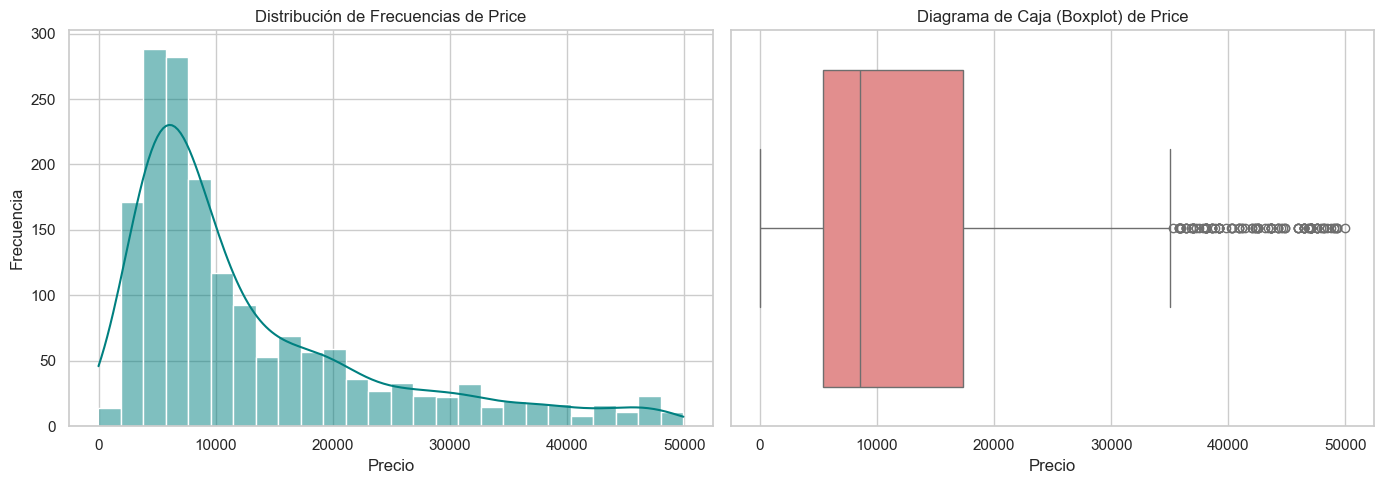

=== DIAGNÓSTICO DE CALIDAD DE DATOS (CRISP-DM) ===

1. Análisis de valores ausentes por columna:


,Valores Nulos,Porcentaje (%)
Seller,2,0.11744


2. Filas totalmente duplicadas en el dataset: 4


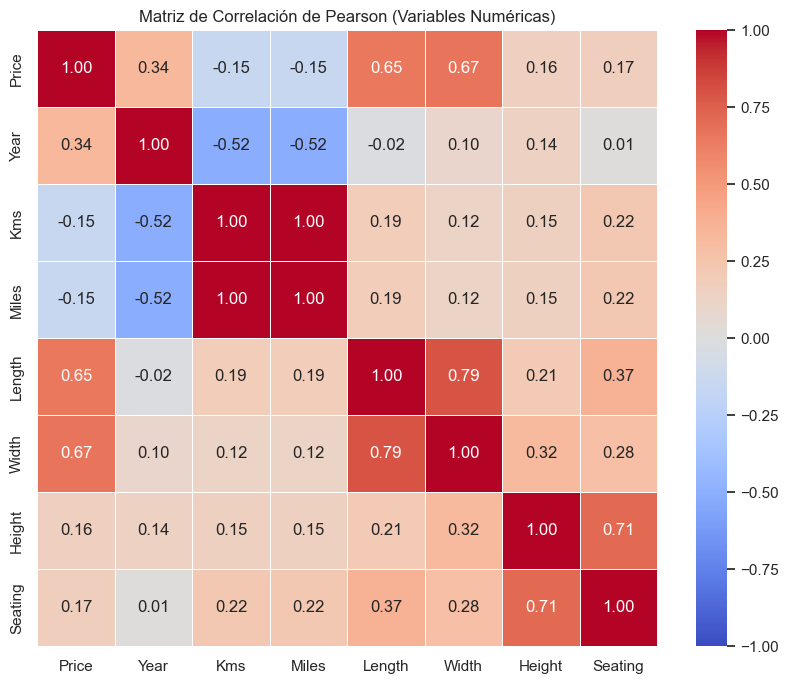

3. Variables con correlación muy alta (redundancia potencial):
   - Kms y Miles tienen una correlación de 1.0000


In [7]:
# 3.1. Visualización de la distribución de la variable objetivo (Target: Price)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con densidad (KDE)
sns.histplot(df['Price'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribución de Frecuencias de Price')
axes[0].set_xlabel('Precio')
axes[0].set_ylabel('Frecuencia')

# Boxplot para identificar outliers (valores atípicos)
sns.boxplot(x=df['Price'], ax=axes[1], color='lightcoral')
axes[1].set_title('Diagrama de Caja (Boxplot) de Price')
axes[1].set_xlabel('Precio')

plt.tight_layout()
plt.show()

# 3.2. Identificación manual y específica de problemas de calidad de datos
print("=== DIAGNÓSTICO DE CALIDAD DE DATOS (CRISP-DM) ===\n")

# A. Valores Ausentes (NaN / Nulls)
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Valores Nulos': missing_data, 'Porcentaje (%)': missing_percent})
print("1. Análisis de valores ausentes por columna:")
display(missing_df[missing_df['Valores Nulos'] > 0])

# B. Filas Completamente Duplicadas
duplicated_count = df.duplicated().sum()
print(f"2. Filas totalmente duplicadas en el dataset: {duplicated_count}")

# C. Colinealidad/Redundancia entre Variables Numéricas
# Calculamos la matriz de correlación de Pearson
numeric_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numeric_cols].corr(method='pearson')

# Mostramos un heatmap visual de las correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación de Pearson (Variables Numéricas)')
plt.show()

# Detectamos pares con correlación perfecta o extremadamente alta (> 0.95)
print("3. Variables con correlación muy alta (redundancia potencial):")
high_corr = correlation_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr > 0.95) & (high_corr < 1.0)].drop_duplicates()
if len(high_corr) > 0:
    for index, val in high_corr.items():
        print(f"   - {index[0]} y {index[1]} tienen una correlación de {val:.4f}")
else:
    print("   - No se encontraron variables altamente correlacionadas.")

4. PREPARACIÓN DE LOS DATOS (Data Preparation)

In [8]:
# 4.1. Limpieza de duplicados
print(f"Dimensiones antes de eliminar duplicados: {df.shape}")
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Dimensiones después de eliminar duplicados: {df_clean.shape}\n")

# 4.2. Selección de características (Eliminar columnas inútiles o redundantes)
# Eliminamos 'Miles' porque posee correlación perfecta con 'Kms' (Multicolinealidad)
X = df_clean.drop(columns=['Price', 'Miles'])
y = df_clean['Price']

print("Variables predictoras (X):", list(X.columns))
print("Variable objetivo (y): 'Price'\n")

# 4.3. Partición de los datos (Train-Test Split)
# Reservamos un 20% de los datos para la validación final (con semilla aleatoria fija)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"Estructura del conjunto de Entrenamiento (Train): X={X_train.shape}, y={y_train.shape}")
print(f"Estructura del conjunto de Validación (Validation): X={X_val.shape}, y={y_val.shape}\n")

# 4.4. Definición de Columnas según su tipo
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print("Variables categóricas detectadas:", categorical_cols)
print("Variables numéricas detectadas:", numeric_cols)

# 4.5. Configuración de transformaciones (Preprocesador con Pipelines)

# Pipeline para variables categóricas:
# - Imputamos nulos con la categoría más frecuente ('most_frequent')
# - Codificamos a OneHotEncoder (ignorando categorías desconocidas en validación)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline para variables numéricas:
# - Imputamos nulos con la mediana (por seguridad, si los hubiera en el futuro)
# - Escalamos con RobustScaler debido a la presencia de outliers en kilómetros y dimensiones
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Unificador del preprocesamiento por columnas (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("\n¡Pipeline de preprocesamiento configurado con éxito!")

Dimensiones antes de eliminar duplicados: (1703, 13)
Dimensiones después de eliminar duplicados: (1699, 13)

Variables predictoras (X): ['Year', 'Kms', 'Fuel', 'Transmission', 'Owner', 'Seller', 'Drivetrain', 'Length', 'Width', 'Height', 'Seating']
Variable objetivo (y): 'Price'

Estructura del conjunto de Entrenamiento (Train): X=(1359, 11), y=(1359,)
Estructura del conjunto de Validación (Validation): X=(340, 11), y=(340,)

Variables categóricas detectadas: ['Fuel', 'Transmission', 'Owner', 'Seller', 'Drivetrain']
Variables numéricas detectadas: ['Year', 'Kms', 'Length', 'Width', 'Height', 'Seating']

¡Pipeline de preprocesamiento configurado con éxito!


5. MODELADO: EVALUACIÓN DE BASELINE (DUMMY) Y REGRESIÓN LINEAL CON CV

In [9]:
from sklearn.model_selection import KFold, cross_validate

# 5.1. Configuración del esquema de validación cruzada (10-Fold CV)
cv_strategy = KFold(n_splits=10, shuffle=True, random_state=42)

# Definimos un diccionario para ir almacenando los resultados de validación cruzada
cv_results_summary = {}

# ------------------------------------------------------------------------------
# MODELO 1: Dummy Regressor (Punto de Referencia / Baseline)
# ------------------------------------------------------------------------------
print("=== Entrenando y evaluando Dummy Regressor (Baseline) ===")

# El Dummy Regressor no necesita preprocesar características porque solo predice la media
dummy_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DummyRegressor(strategy='mean'))
])

# Ejecutamos Validación Cruzada utilizando MAE como métrica (negated MAE en sklearn)
dummy_cv = cross_validate(
    dummy_pipe, X_train, y_train,
    cv=cv_strategy,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    n_jobs=-1
)

# Guardamos el MAE promedio (cambiando el signo a positivo)
dummy_mae_train = -dummy_cv['train_score'].mean()
dummy_mae_val = -dummy_cv['test_score'].mean()
cv_results_summary['Dummy Regressor (Mean)'] = dummy_mae_val

print(f"Dummy Regressor -> MAE de Entrenamiento (Train MAE): {dummy_mae_train:.2f}")
print(f"Dummy Regressor -> MAE de Validación Promedio (CV Val MAE): {dummy_mae_val:.2f}\n")


# ------------------------------------------------------------------------------
# MODELO 2: Regresión Lineal (Linear Regression)
# ------------------------------------------------------------------------------
print("=== Entrenando y evaluando Linear Regression ===")

# Encapsulamos el preprocesador y el modelo de regresión lineal en un Pipeline unificado
lr_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Evaluamos con la misma estrategia de 10-Fold CV para que la comparación sea justa
lr_cv = cross_validate(
    lr_pipe, X_train, y_train,
    cv=cv_strategy,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    n_jobs=-1
)

# Extraemos y promediamos las métricas
lr_mae_train = -lr_cv['train_score'].mean()
lr_mae_val = -lr_cv['test_score'].mean()
cv_results_summary['Linear Regression'] = lr_mae_val

print(f"Linear Regression -> MAE de Entrenamiento (Train MAE): {lr_mae_train:.2f}")
print(f"Linear Regression -> MAE de Validación Promedio (CV Val MAE): {lr_mae_val:.2f}\n")


# 5.2. Comparación inicial
print("=== COMPARACIÓN INICIAL DE RENDIMIENTO ===")
for model_name, mae in cv_results_summary.items():
    print(f"- {model_name}: MAE en CV = {mae:.2f}")

=== Entrenando y evaluando Dummy Regressor (Baseline) ===
Dummy Regressor -> MAE de Entrenamiento (Train MAE): 8395.78
Dummy Regressor -> MAE de Validación Promedio (CV Val MAE): 8397.76

=== Entrenando y evaluando Linear Regression ===
Linear Regression -> MAE de Entrenamiento (Train MAE): 3988.39
Linear Regression -> MAE de Validación Promedio (CV Val MAE): 4048.70

=== COMPARACIÓN INICIAL DE RENDIMIENTO ===
- Dummy Regressor (Mean): MAE en CV = 8397.76
- Linear Regression: MAE en CV = 4048.70


5. MODELO ELASTICNET CON OPTIMIZACIÓN DE HIPERPARÁMETROS

In [19]:
print("Configurando Pipeline para ElasticNet...")

# 1. Re-detectar las columnas reales que existen actualmente en X_train
# Esto evita errores si eliminaste columnas como 'Miles' en la fase de preparación de datos
numeric_features_en = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_en = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Re-construir un ColumnTransformer limpio con las características presentes en X_train
preprocessor_en = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_en),      # Reutiliza el pipeline numérico (imputer + scaling)
        ('cat', categorical_transformer, categorical_features_en) # Reutiliza el pipeline categórico (imputer + one-hot)
    ]
)

# 3. Definir el Pipeline unificado para ElasticNet
elasticnet_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_en),
    ('regressor', ElasticNet(random_state=42, max_iter=10000))
])

# 4. Definir la rejilla de búsqueda de hiperparámetros (Tuning)
# alpha: controla la fuerza de la penalización.
# l1_ratio: 0.0 es Ridge (L2), 1.0 es Lasso (L1), valores intermedios combinan ambas.
param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

# 5. Configurar GridSearchCV usando la misma estrategia de folds (cv_strategy)
grid_search_en = GridSearchCV(
    estimator=elasticnet_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,  # Reutiliza la estrategia kf de 10-folds definida anteriormente
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    n_jobs=-1
)

# 6. Ajustar el modelo con los datos de entrenamiento
print("Ejecutando Grid Search para ElasticNet...")
grid_search_en.fit(X_train, y_train)

# 7. Extraer métricas de la búsqueda
best_en_idx = grid_search_en.best_index_
elasticnet_cv_train_mae = -grid_search_en.cv_results_['mean_train_score'][best_en_idx]
elasticnet_cv_val_mae = -grid_search_en.cv_results_['mean_test_score'][best_en_idx]

# 8. Almacenar el resultado en el diccionario comparativo global para tu comparativa final
cv_results_summary['ElasticNet'] = elasticnet_cv_val_mae

# 9. Mostrar resultados
print("\n" + "="*50)
print("=== RESULTADOS ELASTICNET ===")
print(f"Mejores Parámetros: {grid_search_en.best_params_}")
print(f"ElasticNet CV Train MAE: {elasticnet_cv_train_mae:.2f}")
print(f"ElasticNet CV Val MAE:   {elasticnet_cv_val_mae:.2f}")
print("="*50)

Configurando Pipeline para ElasticNet...
Ejecutando Grid Search para ElasticNet...

=== RESULTADOS ELASTICNET ===
Mejores Parámetros: {'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.5}
ElasticNet CV Train MAE: 3970.54
ElasticNet CV Val MAE:   4010.47


MODELO: RANDOM FOREST (Tuned)

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

print("--- Iniciando optimización para Random Forest ---")

# 1. Re-detectamos las columnas existentes en X_train de manera dinámica para evitar errores de columnas eliminadas (como 'Miles')
numeric_features_rf = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_rf = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Re-construimos el preprocesador limpio y compatible con las columnas reales de X_train
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_rf),
        ('cat', categorical_transformer, categorical_features_rf)
    ]
)

# 3. Creamos el pipeline unificado utilizando el preprocesador limpio
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# 4. Definimos la distribución de hiperparámetros a explorar
rf_param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 20, 30, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': [1.0, 'sqrt', 'log2']
}

# 5. Configuramos e iniciamos la búsqueda aleatoria
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=15,  # Número de combinaciones aleatorias a probar
    cv=cv_strategy, # Estrategia kf de 10-folds definida anteriormente
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

# 6. Extraemos métricas de validación cruzada
best_rf_idx = rf_search.best_index_
rf_cv_train_mae = -rf_search.cv_results_['mean_train_score'][best_rf_idx]
rf_cv_val_mae = -rf_search.cv_results_['mean_test_score'][best_rf_idx]

print(f"Mejores parámetros RF: {rf_search.best_params_}")
print(f"RF CV Train MAE: {rf_cv_train_mae:.2f}")
print(f"RF CV Validation MAE: {rf_cv_val_mae:.2f}\n")

--- Iniciando optimización para Random Forest ---
Mejores parámetros RF: {'rf__n_estimators': 300, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 1.0, 'rf__max_depth': 30}
RF CV Train MAE: 711.93
RF CV Validation MAE: 1906.89



MODELO: HIST GRADIENT BOOSTING (Tuned)

In [14]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

print("--- Iniciando optimización para HistGradientBoosting ---")

# 1. Re-detectamos las columnas de forma dinámica para asegurar compatibilidad
numeric_features_hgb = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_hgb = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Re-construimos el preprocesador limpio para las columnas reales de X_train
preprocessor_hgb = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_hgb),
        ('cat', categorical_transformer, categorical_features_hgb)
    ]
)

# 3. Creamos el pipeline unificado utilizando el preprocesador limpio
hgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_hgb),
    ('hgb', HistGradientBoostingRegressor(random_state=42))
])

# 4. Definimos la distribución de hiperparámetros a explorar
hgb_param_dist = {
    'hgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'hgb__max_iter': [100, 150, 200, 300],
    'hgb__max_depth': [3, 5, 8, 12, None],
    'hgb__min_samples_leaf': [10, 20, 40, 60],
    'hgb__l2_regularization': [0.0, 0.1, 1.0, 10.0]
}

# 5. Configuramos e iniciamos la búsqueda aleatoria
hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=hgb_param_dist,
    n_iter=20,  # Probamos un poco más ya que GBDT entrena extremadamente rápido
    cv=cv_strategy, # Estrategia kf de 10-folds definida anteriormente
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    random_state=42,
    n_jobs=-1
)

hgb_search.fit(X_train, y_train)

# 6. Extraemos métricas de validación cruzada
best_hgb_idx = hgb_search.best_index_
hgb_cv_train_mae = -hgb_search.cv_results_['mean_train_score'][best_hgb_idx]
hgb_cv_val_mae = -hgb_search.cv_results_['mean_test_score'][best_hgb_idx]

print(f"Mejores parámetros HGB: {hgb_search.best_params_}")
print(f"HGB CV Train MAE: {hgb_cv_train_mae:.2f}")
print(f"HGB CV Validation MAE: {hgb_cv_val_mae:.2f}\n")

--- Iniciando optimización para HistGradientBoosting ---
Mejores parámetros HGB: {'hgb__min_samples_leaf': 20, 'hgb__max_iter': 300, 'hgb__max_depth': None, 'hgb__learning_rate': 0.05, 'hgb__l2_regularization': 0.1}
HGB CV Train MAE: 858.55
HGB CV Validation MAE: 1834.65



7. EVALUACIÓN DE TABPFN V3 (REGRESSOR)

In [16]:
import numpy as np
from tabpfn import TabPFNRegressor
from sklearn.model_selection import cross_validate

# 1. Definir la ruta local al checkpoint de TabPFN v3 Regressor
checkpoint_path = r"C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\tabpfn_driver\tabpfn-v3-regressor-v3_20260417_mediumdata.ckpt"

print("Inicializando TabPFN Regressor v3...")
# 2. Inicializar el regresor apuntando al archivo local (.ckpt)
# Añadimos ignore_pretraining_limits=True para evitar el error de límite de muestras en CPU
tabpfn_regressor = TabPFNRegressor(
    model_path=checkpoint_path,
    device='cpu',  # Cambiar a 'cuda' si dispones de una GPU compatible en tu entorno
    ignore_pretraining_limits=True  # <--- Soluciona el error de límite de 1000 muestras
)

# 3. Ejecutar validación cruzada usando la misma estrategia de folds (cv_strategy)
print("Ejecutando validación cruzada con TabPFN...")
tabpfn_cv_results = cross_validate(
    estimator=tabpfn_regressor,
    X=X_train,
    y=y_train,
    cv=cv_strategy,  # Reutiliza la estrategia kf de 10-folds definida anteriormente
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    n_jobs=1  # TabPFN paraleliza internamente; dejamos n_jobs=1 para evitar conflictos en CPU
)

# 4. Extraer y procesar métricas (convertir a valores positivos de MAE)
tabpfn_cv_train_mae = -tabpfn_cv_results['train_score'].mean()
tabpfn_cv_val_mae = -tabpfn_cv_results['test_score'].mean()

# Añadir los resultados al diccionario global para tu comparativa final
cv_results_summary['TabPFN v3'] = tabpfn_cv_val_mae

# 5. Mostrar resultados por pantalla para comparar
print("\n" + "="*50)
print("RESULTADOS TABPFN V3 REGRESSOR:")
print(f"TabPFN CV Train MAE: {tabpfn_cv_train_mae:.2f}")
print(f"TabPFN CV Val MAE:   {tabpfn_cv_val_mae:.2f}")
print("="*50)

Inicializando TabPFN Regressor v3...
Ejecutando validación cruzada con TabPFN...

RESULTADOS TABPFN V3 REGRESSOR:
TabPFN CV Train MAE: 937.25
TabPFN CV Val MAE:   1487.30


8. EVALUACIÓN FINAL EN EL CONJUNTO DE TEST